In [1]:
from ultralytics import YOLO

model = YOLO(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\runs\detect\runs\sensegen\yolo11n_quick\weights\best.pt"
)

print("SenseGen model loaded successfully!")

SenseGen model loaded successfully!


In [2]:
results = model.val(
    data=r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\data.yaml",
    split="test",
    imgsz=320,
    batch=16
)

print("Test evaluation completed!")

Ultralytics 8.4.165  Python-3.13.9 torch-2.14.0+cpu CPU (12th Gen Intel Core i5-1235U)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.40.1 ms, read: 8.52.2 MB/s, size: 71.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\labels... 545 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 545/545 394.2it/s 1.4s0.0s
val: C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\images\pipe_videoplaybackasdf_900_jpg.rf.543431951ae94531b2d48827301533bf.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [ 5. 10.]
val: New cache created: C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3

Testing image: -11-_jpeg_jpg.rf.9b1eb73ac34f626447734ff4cdd40255.jpg

image 1/1 C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\images\-11-_jpeg_jpg.rf.9b1eb73ac34f626447734ff4cdd40255.jpg: 320x320 2 garbage_overflows, 60.7ms
Speed: 6.2ms preprocess, 60.7ms inference, 5.0ms postprocess per image at shape (1, 3, 320, 320)


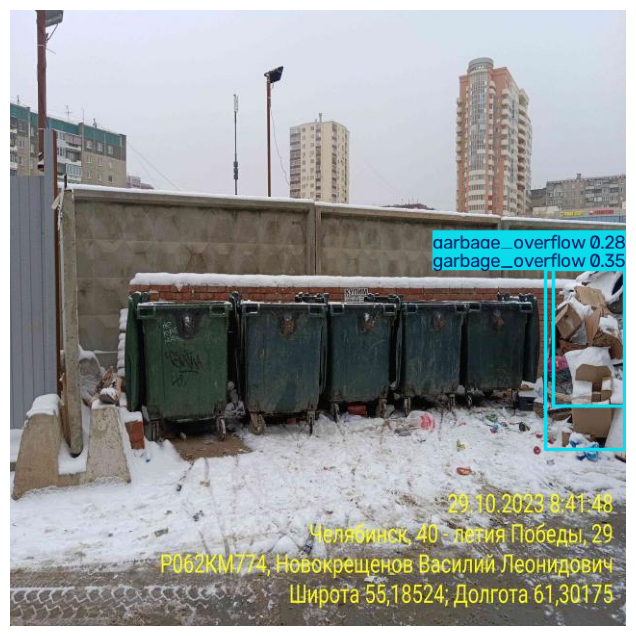

In [3]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Pick one image from the test dataset
test_images = list(
    Path(r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\images").glob("*")
)

image_path = test_images[0]

print("Testing image:", image_path.name)

# Run prediction
results = model.predict(
    source=str(image_path),
    conf=0.25,
    imgsz=320
)

# Display prediction
annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.show()


Testing: water_leakage
Image: pipe_-_jpg.rf.7eff9c349fa59e149768e37e0438cb51.jpg


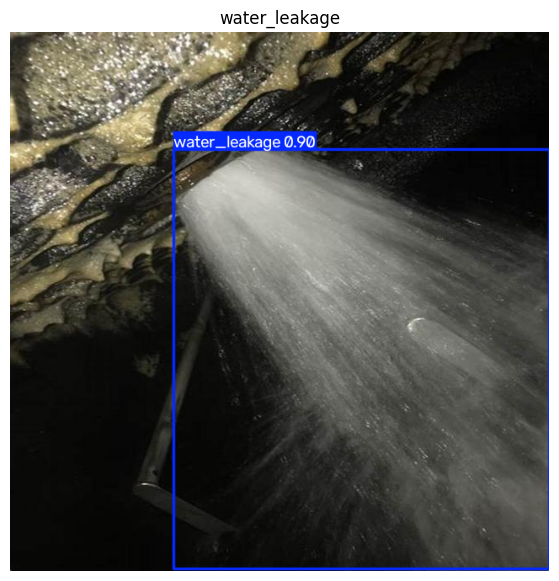


Testing: garbage_overflow
Image: -11-_jpeg_jpg.rf.9b1eb73ac34f626447734ff4cdd40255.jpg


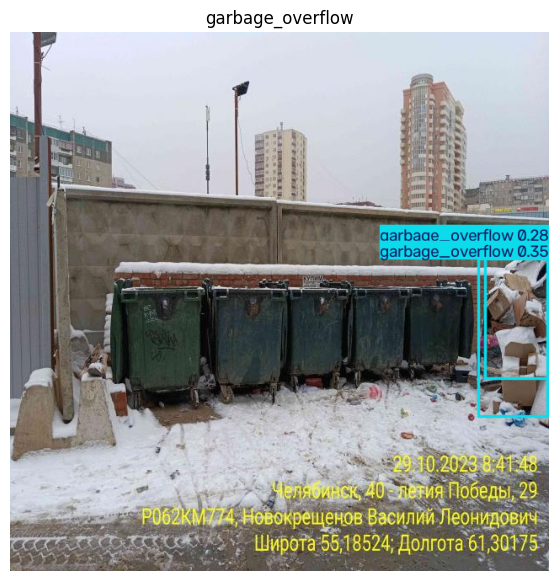


Testing: fire_accident
Image: 000074_jpg.rf.ae5259529c2409ae38300345c11bd84a.jpg


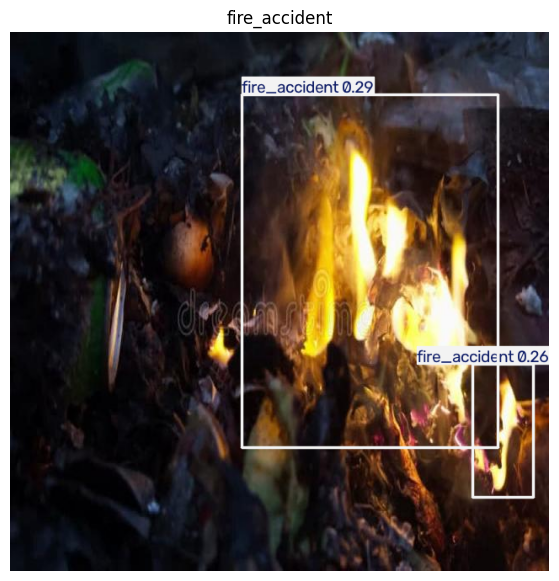


Testing: fallen_tree
Image: 40_jpg.rf.63605f9905e0df197db8c3ac92bf7999.jpg


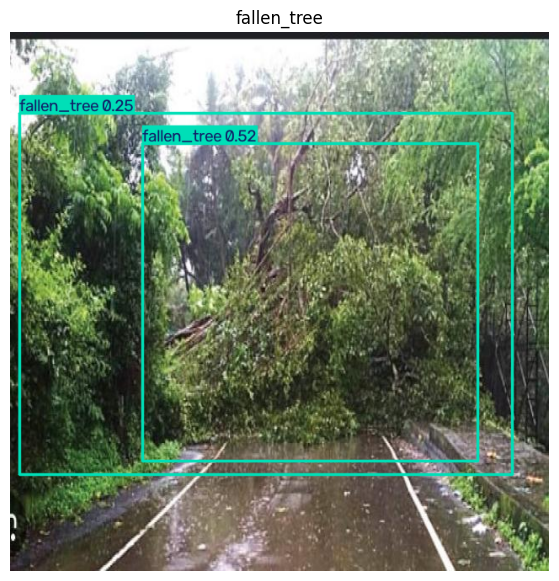


Testing: road_damage
Image: 0019_png_jpg.rf.dd1778d1cae2c5fc6bce587c3d3af947.jpg


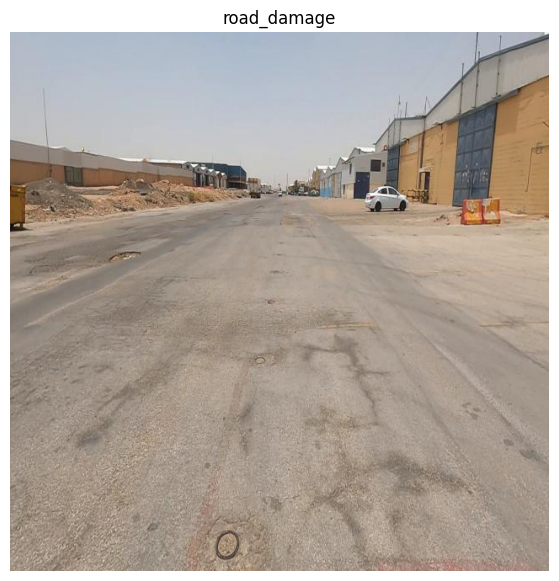

In [4]:
from pathlib import Path
import random
import matplotlib.pyplot as plt

class_names = {
    0: "water_leakage",
    1: "garbage_overflow",
    2: "fire_accident",
    3: "fallen_tree",
    4: "road_damage"
}

test_images_dir = Path(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\images"
)

test_labels_dir = Path(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\test\labels"
)

selected_images = {}

# Find one image containing each class
for label_file in test_labels_dir.glob("*.txt"):
    with open(label_file, "r") as f:
        lines = f.readlines()

    classes_in_image = set()

    for line in lines:
        parts = line.strip().split()
        if parts:
            classes_in_image.add(int(parts[0]))

    for class_id in classes_in_image:
        if class_id not in selected_images:
            image_file = test_images_dir / (label_file.stem + ".jpg")

            if image_file.exists():
                selected_images[class_id] = image_file

# Run prediction for each class
for class_id in range(5):

    if class_id not in selected_images:
        print(f"No image found for {class_names[class_id]}")
        continue

    image_path = selected_images[class_id]

    print(f"\nTesting: {class_names[class_id]}")
    print(f"Image: {image_path.name}")

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=320,
        verbose=False
    )

    annotated = results[0].plot()

    plt.figure(figsize=(10, 7))
    plt.imshow(annotated[:, :, ::-1])
    plt.title(class_names[class_id])
    plt.axis("off")
    plt.show()
    

In [5]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11n pretrained model loaded successfully!")

YOLO11n pretrained model loaded successfully!


In [6]:
results = model.train(
    data=r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v2\data.yaml",
    epochs=30,
    imgsz=320,
    batch=16,
    patience=5,
    project=r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\runs\sensegen_v2",
    name="yolo11n_v2"
)

Ultralytics 8.4.165  Python-3.13.9 torch-2.14.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v2\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11n pretrained model loaded successfully!")

YOLO11n pretrained model loaded successfully!


In [8]:
results = model.train(
    data=r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\data.yaml",
    epochs=15,
    imgsz=320,
    batch=16,
    patience=5,
    project=r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\runs\sensegen_v3",
    name="yolo11n_v3"
)

Ultralytics 8.4.165  Python-3.13.9 torch-2.14.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

In [9]:
from ultralytics import YOLO

model = YOLO(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\runs\sensegen_v3\yolo11n_v3\weights\best.pt"
)

print("SenseGen V3 best model loaded successfully!")

SenseGen V3 best model loaded successfully!


In [10]:
test_results = model.val(
    data=r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\data.yaml",
    split="test",
    imgsz=320,
    batch=16
)

print("FINAL TEST EVALUATION COMPLETED!")

Ultralytics 8.4.165  Python-3.13.9 torch-2.14.0+cpu CPU (12th Gen Intel Core i5-1235U)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.1 ms, read: 42.236.8 MB/s, size: 49.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels... 485 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 485/485 527.2it/s 0.9s0.1s
val: New cache created: C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 3.0it/s 10.4s0.3s
                   all        485        726       0.65      0.598      0.641      0.347
         water_leakage        165        184      0.746      0

In [11]:
from ultralytics import YOLO

model = YOLO(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\runs\sensegen_v3\yolo11n_v3\weights\best.pt"
)

print(model.names)

{0: 'water_leakage', 1: 'garbage_overflow', 2: 'fire_accident', 3: 'fallen_tree', 4: 'road_damage', 5: 'streetlight_failure'}


In [12]:
from pathlib import Path

test_labels = Path(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels"
)

for class_id, class_name in model.names.items():

    found = None

    for label_file in test_labels.glob("*.txt"):

        with open(label_file, "r") as f:
            for line in f:

                parts = line.strip().split()

                if parts and int(parts[0]) == class_id:
                    found = label_file
                    break

        if found:
            break

    print(class_id, class_name, "→", found)

0 water_leakage → C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels\pipe_-_jpg.rf.7eff9c349fa59e149768e37e0438cb51.txt
1 garbage_overflow → C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels\garbage_-11-_jpeg_jpg.rf.9b1eb73ac34f626447734ff4cdd40255.txt
2 fire_accident → C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels\fire_000074_jpg.rf.ae5259529c2409ae38300345c11bd84a.txt
3 fallen_tree → C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels\tree_40_jpg.rf.63605f9905e0df197db8c3ac92bf7999.txt
4 road_damage → C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels\pothole_0019_png_jpg.rf.dd1778d1cae2c5fc6bce587c3d3af947.txt
5 streetlight_failure → C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels\streetlight_1709693294364_jpg.rf.4f697f1c9afaca


Actual class : water_leakage
Image        : pipe_-_jpg.rf.7eff9c349fa59e149768e37e0438cb51.jpg
Predicted    : water_leakage | Confidence: 0.36


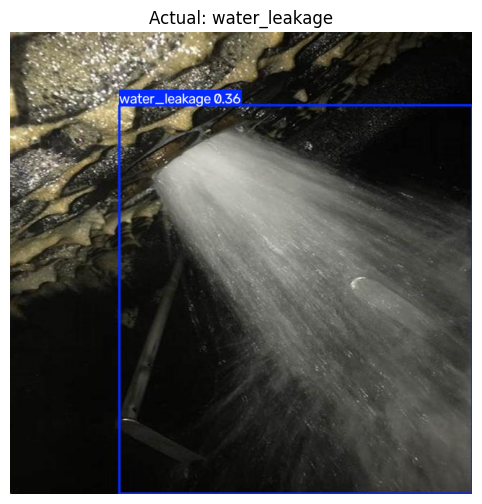


Actual class : garbage_overflow
Image        : garbage_-11-_jpeg_jpg.rf.9b1eb73ac34f626447734ff4cdd40255.jpg
Predicted    : garbage_overflow | Confidence: 0.64
Predicted    : garbage_overflow | Confidence: 0.39


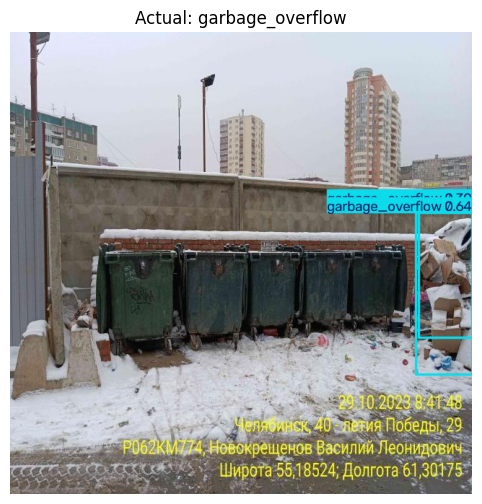


Actual class : fire_accident
Image        : fire_000074_jpg.rf.ae5259529c2409ae38300345c11bd84a.jpg
Predicted    : fire_accident | Confidence: 0.32
Predicted    : fire_accident | Confidence: 0.30
Predicted    : fire_accident | Confidence: 0.30


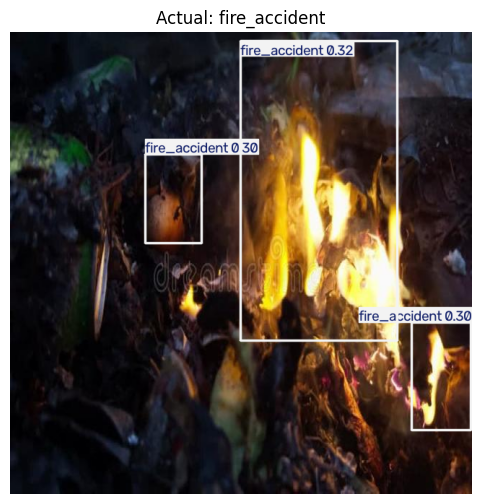


Actual class : fallen_tree
Image        : tree_40_jpg.rf.63605f9905e0df197db8c3ac92bf7999.jpg
Predicted    : No detection


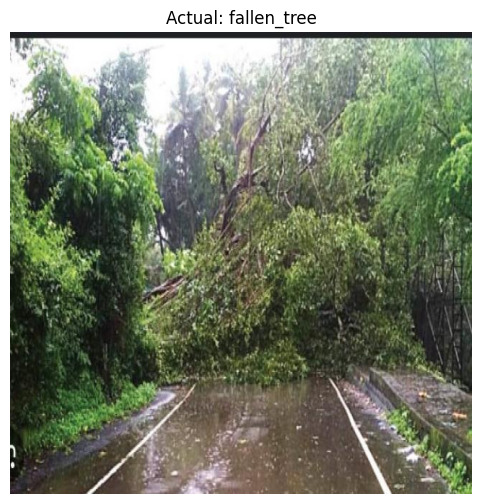


Actual class : road_damage
Image        : pothole_0019_png_jpg.rf.dd1778d1cae2c5fc6bce587c3d3af947.jpg
Predicted    : road_damage | Confidence: 0.40
Predicted    : road_damage | Confidence: 0.39
Predicted    : road_damage | Confidence: 0.34


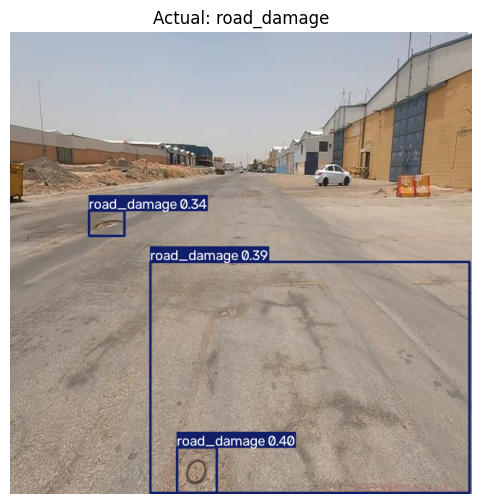


Actual class : streetlight_failure
Image        : streetlight_1709693294364_jpg.rf.4f697f1c9afaca466bb311616434e0d0.jpg
Predicted    : streetlight_failure | Confidence: 0.70


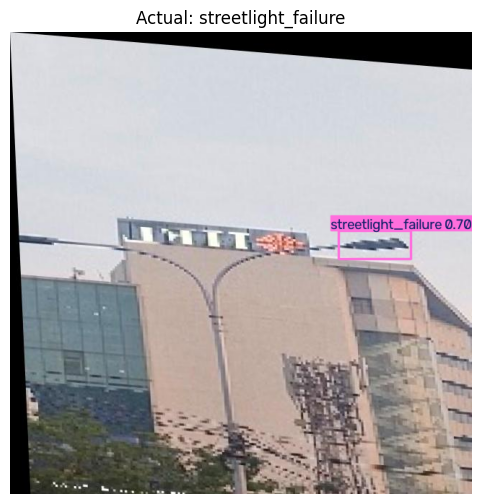

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

test_labels = Path(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\labels"
)

test_images = Path(
    r"C:\Users\pindi\OneDrive\Desktop\SenseGen_Final_Dataset\SenseGen_Final_Dataset_v3\test\images"
)

for class_id, class_name in model.names.items():

    # Find a label containing this class
    label_file = None

    for file in test_labels.glob("*.txt"):
        with open(file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if parts and int(parts[0]) == class_id:
                    label_file = file
                    break

        if label_file:
            break

    if label_file is None:
        print("No test image found for:", class_name)
        continue

    # Find corresponding image
    image_file = None

    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        candidate = test_images / (label_file.stem + ext)

        if candidate.exists():
            image_file = candidate
            break

    if image_file is None:
        print("Image not found for:", class_name)
        continue

    # Run prediction
    results = model.predict(
        source=str(image_file),
        imgsz=320,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    print("\n" + "=" * 50)
    print("Actual class :", class_name)
    print("Image        :", image_file.name)

    if result.boxes is not None and len(result.boxes) > 0:

        for box in result.boxes:
            predicted_id = int(box.cls[0])
            confidence = float(box.conf[0])

            print(
                f"Predicted    : {model.names[predicted_id]}"
                f" | Confidence: {confidence:.2f}"
            )

    else:
        print("Predicted    : No detection")

    # Display prediction
    annotated = result.plot()

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated[:, :, ::-1])
    plt.title(f"Actual: {class_name}")
    plt.axis("off")
    plt.show()